<a href="https://colab.research.google.com/github/daningMontano/ACUS_ECOSYSTEM_ZCH/blob/main/Notebooks/Biomass/0_Data_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Extraction**

By: Daning Montaño Ocampo
Date: 14/4/2026

A 10 m resolution foundational model from Google’s AlphaEarth was used, representing each pixel as a 64-dimensional embedding vector. Biomass training data were obtained from GEDI.

# **1. Libraries**

In [1]:
import pandas as pd
import numpy as np
import geemap
import ee
import os
import geopandas as gpd
import json
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# **2. Initialize**

In [2]:
# Trigger the authentication flow.
#  Autenticar la cuenta de Google Earth Engine
ee.Authenticate()
ee.Initialize(project='monitoreofpachamama')

# **3. Data**

## 3.1. AOI

In [3]:
aoi = ee.FeatureCollection('projects/monitoreofpachamama/assets/ZamoraCH/Provincia_ZCh_5km_buffer')

## 3.2. GEDI - Biomass

### Filter

In [57]:
def clip_image(image):
  """Clips the input image by the geometry."""
  return image.clip(aoi)

bands = [
    'agbd',
    'algorithm_run_flag',
    'degrade_flag',
    'l4_quality_flag',
    'sensitivity',
    'predictor_limit_flag',
    'response_limit_flag',
    'surface_flag',
    'solar_elevation',
    'agbd_se'
]

# --- 1) Carga de datos de elevación para filtro de pendiente ---
srtm = ee.Image('USGS/SRTMGL1_003')
slope = ee.Terrain.slope(srtm)

# ——————————————
# 2) Definimos la máscara de calidad reforzada (incluyendo pendiente)
def quality_mask(image):
    # a) Flags de calidad básicos
    m1 = image.select('l4_quality_flag').eq(1)
    m3 = image.select("algorithm_run_flag").eq(1)

    # b) degrade_flag == 0 (sin degradación de geolocalización)
    m2 = image.select('degrade_flag').eq(0)

    # c) Sensibilidad muy alta (>= 0.95) para máxima penetración
    m4 = image.select('sensitivity').gte(0.95)

    # d) Solo datos nocturnos (solar_elevation < -5) para evitar ruido solar
    m5 = image.select('solar_elevation').lt(-5)

    # e) Error relativo muy bajo (<= 10%)
    relative_se = image.select('agbd_se').divide(image.select('agbd'))
    m6 = relative_se.lte(0.10)

    # f) Rango biofísico realista (mayor a 0  a 600 Mg/ha)
    m7 = image.select("agbd").gte(0).And(image.select("agbd").lte(600))

    # g) Filtro de Pendiente: Menor a 30 grados
    # Remuestreamos la pendiente para que coincida con la escala de GEDI si es necesario
    slope_mask = slope.lt(30)

    # Combina todas las máscaras
    mask = m1.And(m2).And(m3).And(m4).And(m5).And(m6).And(m7).And(slope_mask)
    return image.updateMask(mask)

gedi_filtered = (
  ee.ImageCollection('LARSE/GEDI/GEDI04_A_002_MONTHLY')
      .filterBounds(aoi)
      .map(clip_image)
      .select(bands)
      .map(quality_mask)
      .select("agbd")
)



### Map

In [58]:
# Crear mapa y centrar en AOI
map = geemap.Map(basemap="Esri.WorldImagery")
map.centerObject(aoi, 10)
visParams = {
    'min': 1,
    'max': 500,
    'palette': ['red', 'orange', 'yellow','green']
}
map.addLayer(gedi_filtered, visParams, "GEDI AGBD (Strict + Slope < 30°)")
#map

### N per year

In [59]:


# 1. Definir los años de interés
years = [2019, 2020, 2021, 2022, 2023, 2024]

annual_stats = []

print("Calculando estadísticas anuales usando gedi_filtered (Strict + Slope < 30°)...")

for year in years:
    # Filtrar la colección ya procesada (gedi_filtered) por año
    yearly_coll = gedi_filtered.filter(ee.Filter.calendarRange(year, year, 'year'))
    count_imgs = yearly_coll.size().getInfo()

    if count_imgs > 0:
        # Reducir a media
        annual_mean_img = yearly_coll.mean()

        # Reducción de región para obtener media y conteo de píxeles
        stats = annual_mean_img.reduceRegion(
            reducer=ee.Reducer.mean().combine(
                reducer2=ee.Reducer.count(),
                sharedInputs=True
            ),
            geometry=aoi,
            scale=25,
            maxPixels=1e13
        ).getInfo()

        # Extraer valores manejando posibles Nones o nombres de bandas combinadas
        mean_val = stats.get('agbd') if stats.get('agbd') is not None else stats.get('agbd_mean')
        count_val = stats.get('agbd_count') if stats.get('agbd_count') is not None else 0

        annual_stats.append({
            'Año': year,
            'Biomasa_Media_Mg_ha': mean_val,
            'Conteo_Pixeles': count_val
        })
    else:
        annual_stats.append({'Año': year, 'Biomasa_Media_Mg_ha': 0, 'Conteo_Pixeles': 0})

# Crear DataFrame y mostrar resultados
df_results_filtered = pd.DataFrame(annual_stats)
print("\n--- Resultados con Filtros Reforzados (Strict + Slope < 30°) ---")
print(df_results_filtered)

Calculando estadísticas anuales usando gedi_filtered (Strict + Slope < 30°)...

--- Resultados con Filtros Reforzados (Strict + Slope < 30°) ---
    Año  Biomasa_Media_Mg_ha  Conteo_Pixeles
0  2019           239.203040           13374
1  2020           245.150626           18009
2  2021           236.462495           17792
3  2022           227.496480           11802
4  2023           169.508832             494
5  2024           223.269415           14572


In [60]:
df_results_filtered["Conteo_Pixeles"].sum()

np.int64(76043)

## **3.3. AlphaEarth embedings**

In [61]:


# Cargar la colección de embeddings anuales
embeddings_col = ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')

# Años solicitados
years_list = [2019, 2020, 2021, 2022, 2023, 2024]

# Diccionario para almacenar las imágenes por año
alpha_earth_embeddings = {}

for year in years_list:
    start_date = f'{year}-01-01'
    end_date = f'{year+1}-01-01'

    # Filtrar por fecha y por el AOI definido anteriormente
    img = embeddings_col.filterDate(start_date, end_date) \
                        .filterBounds(aoi) \
                        .first() \
                        .clip(aoi)

    alpha_earth_embeddings[year] = img

# Verificación simple: imprimir las bandas de un año
print(f"Bandas disponibles (Ejemplo {years_list[0]}):", alpha_earth_embeddings[years_list[0]].bandNames().getInfo()[:10], "...")
print(f"Embeddings cargados para los años: {list(alpha_earth_embeddings.keys())}")

Bandas disponibles (Ejemplo 2019): ['A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09'] ...
Embeddings cargados para los años: [2019, 2020, 2021, 2022, 2023, 2024]


## **3.4. Extract data using GEDI per year**

In [62]:
all_samples = []
years_to_process = [2019, 2020, 2021, 2022,2023, 2024]

print("Iniciando extracción exacta de píxeles válidos...")

for year in years_to_process:
    print(f"Procesando año: {year}...")

    # 1. GEDI promedio anual (los píxeles válidos)
    gedi_year_img = gedi_filtered.filter(ee.Filter.calendarRange(year, year, 'year')).mean()

    # 2. Embeddings
    emb_year = alpha_earth_embeddings[year]

    # 3. Crear bandas de coordenadas (latitud y longitud)
    coords = ee.Image.pixelLonLat()

    # 4. Combinar GEDI, Embeddings y Coordenadas
    combined = gedi_year_img.addBands(emb_year).addBands(coords)

    # 5. FORZAR una máscara común estricta
    # Intersectamos la máscara de GEDI con la máscara de los embeddings.
    # reduce(ee.Reducer.min()) asegura que si falta 1 sola banda del embedding, se descarte todo el píxel.
    common_mask = gedi_year_img.mask().And(emb_year.mask().reduce(ee.Reducer.min()))
    combined = combined.updateMask(common_mask)

    # 6. Extraer los datos directamente a listas (sin muestreo espacial aleatorio)
    try:
        data = combined.reduceRegion(
            reducer=ee.Reducer.toList(),
            geometry=aoi,
            scale=25, # Escala de GEDI
            maxPixels=1e13
        ).getInfo()

        # Comprobar si hay datos
        if data and 'agbd' in data and len(data['agbd']) > 0:
            n_points = len(data['agbd'])
            print(f"  - Se extrajeron {n_points} puntos exactos para {year}.")

            # Crear DataFrame temporal para el año
            df_year = pd.DataFrame(data)
            df_year['year'] = year
            all_samples.append(df_year)
        else:
            print(f"  - No se encontraron puntos válidos para {year}.")

    except Exception as e:
        print(f"  - Error en el año {year}: {e}")

# Unir todos los años en un solo DataFrame
if len(all_samples) > 0:
    df_final = pd.concat(all_samples, ignore_index=True)
    # Reordenar columnas para que lat/lon, year y agbd estén al principio
    cols = ['year', 'longitude', 'latitude', 'agbd']
    emb_cols = [c for c in df_final.columns if c.startswith('A')]
    df_final = df_final[cols + emb_cols]
else:
    df_final = pd.DataFrame()

print(f"\nExtracción finalizada. Total de muestras en el dataset: {len(df_final)}")
display(df_final.head())

Iniciando extracción exacta de píxeles válidos...
Procesando año: 2019...
  - Se extrajeron 8402 puntos exactos para 2019.
Procesando año: 2020...
  - Se extrajeron 13080 puntos exactos para 2020.
Procesando año: 2021...
  - Se extrajeron 11234 puntos exactos para 2021.
Procesando año: 2022...
  - Se extrajeron 7495 puntos exactos para 2022.
Procesando año: 2023...
  - Se extrajeron 22 puntos exactos para 2023.
Procesando año: 2024...
  - Se extrajeron 6437 puntos exactos para 2024.

Extracción finalizada. Total de muestras en el dataset: 46670


,year,longitude,latitude,agbd,A00,A01,A02,A03,A04,A05,...,A54,A55,A56,A57,A58,A59,A60,A61,A62,A63
0,2019,-78.598657,-4.530092,265.520142,0.027128,0.015748,-0.059116,-0.027128,0.044844,-0.135886,...,0.130165,0.119093,0.141730,-0.024606,0.071111,-0.024606,0.179377,-0.098424,0.172795,-0.027128
1,2019,-78.598433,-4.529643,308.824371,0.006151,0.055363,-0.019931,-0.013841,0.062991,-0.108512,...,0.071111,0.103406,0.103406,-0.044844,0.066990,-0.075356,0.079723,-0.071111,0.172795,-0.113741
2,2019,-78.597983,-4.529193,566.537292,0.044844,0.029773,-0.059116,-0.041584,0.066990,-0.179377,...,0.038447,0.098424,0.071111,-0.022207,0.038447,-0.055363,0.098424,-0.108512,0.098424,-0.075356
3,2019,-78.597759,-4.528744,358.417023,0.051734,0.066990,-0.015748,-0.062991,0.066990,-0.206936,...,0.019931,0.044844,0.075356,-0.022207,0.044844,-0.075356,0.071111,-0.141730,0.071111,-0.079723
4,2019,-78.597534,-4.528295,240.732971,0.027128,0.084214,-0.007443,-0.044844,0.088827,-0.172795,...,-0.008858,0.059116,0.075356,-0.035433,0.044844,-0.075356,0.041584,-0.124567,0.051734,-0.093564


In [63]:
df_final.shape

(46670, 68)

# **4.EDA**

## 4.1. Correlation Matrix (first 10 emb)

In [64]:
df_final["agbd"].max()

599.882874

In [65]:
df_final["agbd"].min()

0.0

<Axes: >

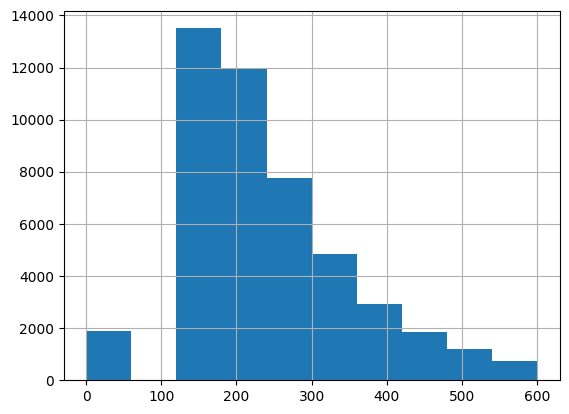

In [66]:
df_final["agbd"].hist()

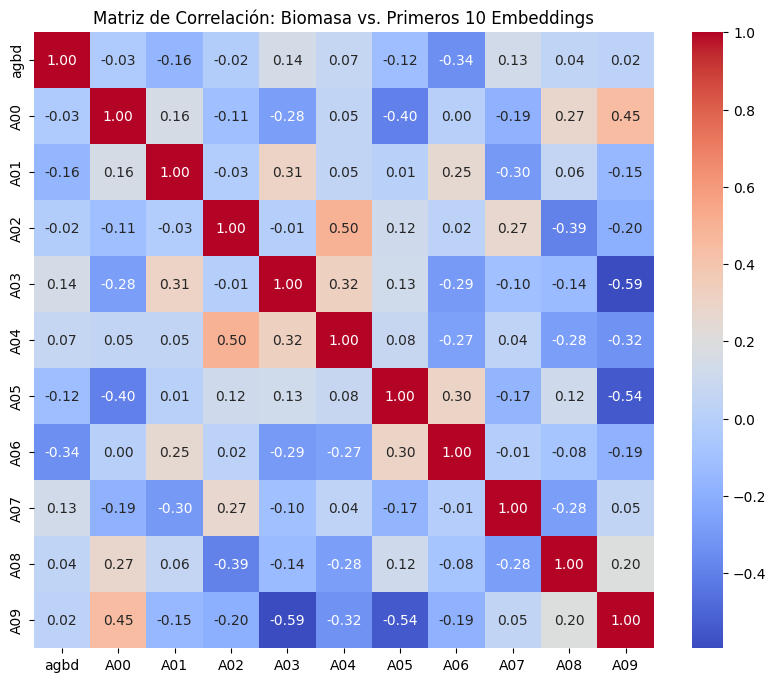

In [67]:
columns_to_correlate = ['agbd'] + [f'A{i:02d}' for i in range(10)]
correlation_matrix = df_final[columns_to_correlate].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación: Biomasa vs. Primeros 10 Embeddings')
plt.show()

## 4.2. Scatter plot

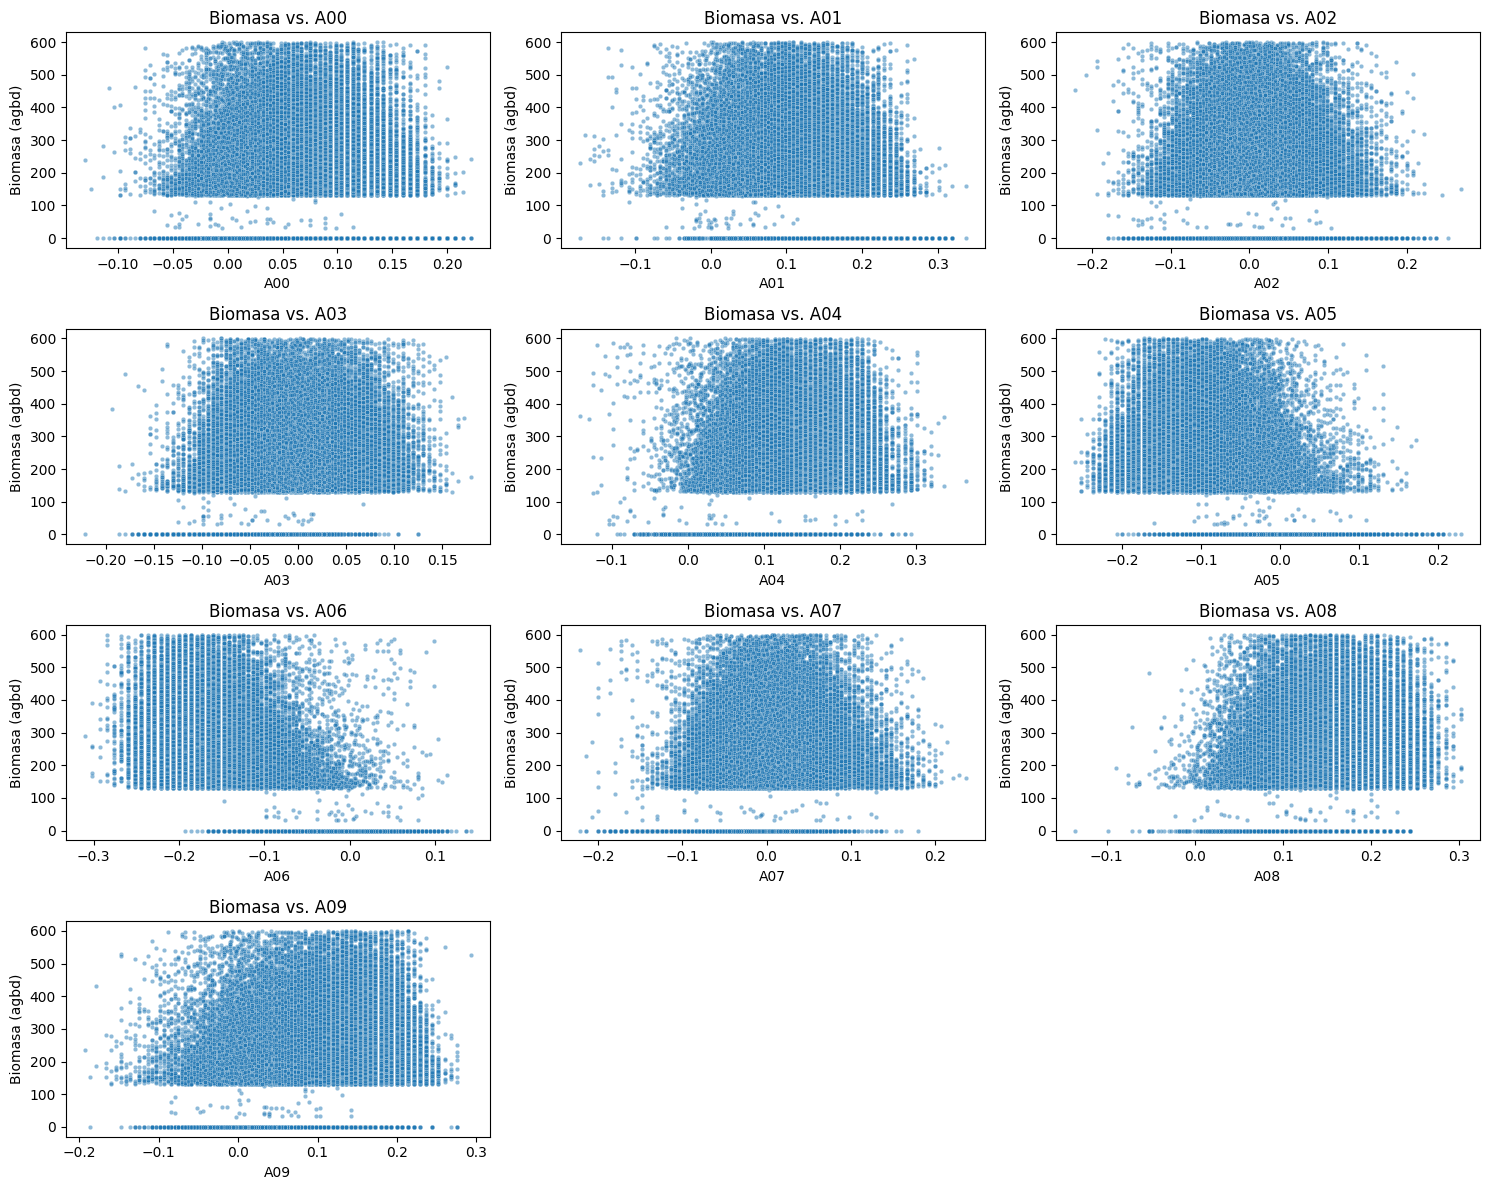

In [68]:
num_embeddings_to_plot = 10

plt.figure(figsize=(15, 12))

for i in range(num_embeddings_to_plot):
    col_name = f'A{i:02d}' # e.g., 'A00', 'A01'

    plt.subplot(4, 3, i + 1) # Create a subplot for each embedding
    sns.scatterplot(data=df_final, x=col_name, y='agbd', alpha=0.5, s=10)
    plt.title(f'Biomasa vs. {col_name}')
    plt.xlabel(col_name)
    plt.ylabel('Biomasa (agbd)')

plt.tight_layout()
plt.show()

## 4.3. PCA

Varianza explicada por cada componente principal:
 [1.82957346e-01 1.63266519e-01 1.30965699e-01 8.83448592e-02
 7.39619149e-02 5.42205210e-02 5.10409619e-02 3.62333412e-02
 2.67103569e-02 2.35757442e-02 1.93120488e-02 1.60360752e-02
 1.43035160e-02 1.22841215e-02 1.14531266e-02 1.06502254e-02
 8.79827196e-03 7.33056558e-03 7.03114876e-03 5.87439080e-03
 4.95665684e-03 4.82984586e-03 4.14049461e-03 3.95105653e-03
 3.08913111e-03 2.88868336e-03 2.69821476e-03 2.41844923e-03
 2.19803254e-03 2.12464126e-03 1.99175878e-03 1.86979779e-03
 1.59406467e-03 1.36600873e-03 1.24109439e-03 1.15325393e-03
 1.07713184e-03 1.06227904e-03 1.00464912e-03 8.14820953e-04
 7.94091637e-04 7.38135050e-04 6.74832701e-04 6.00535308e-04
 5.89375047e-04 5.43713109e-04 4.95293162e-04 4.87215395e-04
 4.02446610e-04 3.90621938e-04 3.61421703e-04 3.33540304e-04
 3.32511337e-04 2.89527356e-04 2.70614150e-04 2.32994674e-04
 2.28920542e-04 2.12472558e-04 1.94169795e-04 1.85815712e-04
 1.67015292e-04 1.57085548e-04 1.3

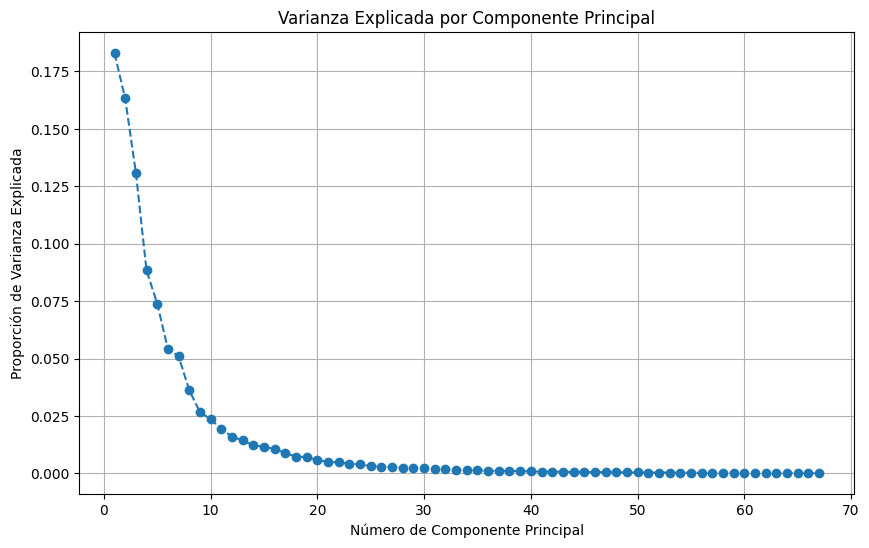

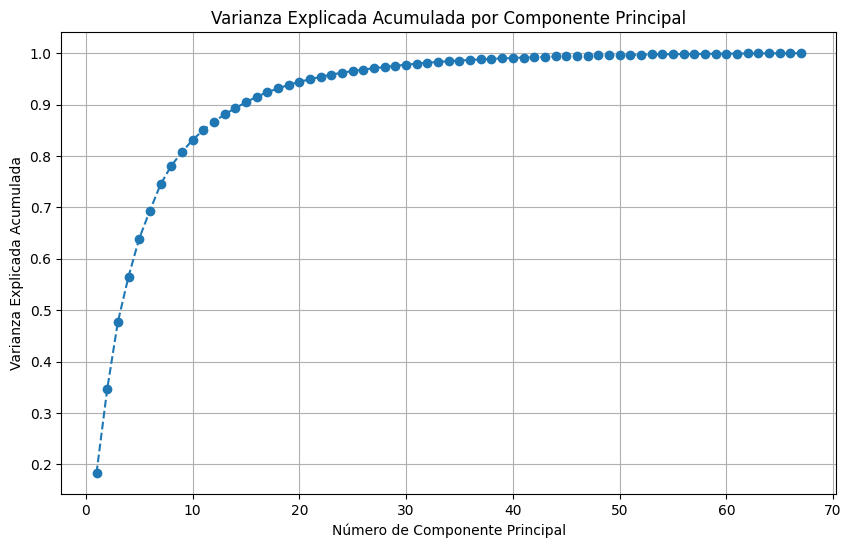


Primeros 5 Componentes Principales y algunas características originales:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC61,PC62,PC63,PC64,PC65,PC66,PC67,longitude,latitude,agbd_original
0,-5.002345,5.699306,-0.999314,-0.770731,-1.977966,-0.059542,3.383274,1.308521,0.521016,-0.409952,...,0.112417,0.011910,-0.129897,0.018353,0.067827,-0.082779,0.054069,-78.598657,-4.530092,265.520142
1,-0.817078,6.507619,-0.548165,0.519491,-1.025690,0.252293,3.821970,-0.515897,1.814246,-0.291530,...,-0.019456,-0.017123,-0.055908,-0.070958,-0.155678,-0.012720,0.036171,-78.598433,-4.529643,308.824371
2,-1.974028,6.821713,2.921131,0.080961,-1.516744,0.427722,3.683628,0.266526,0.245025,0.365466,...,-0.061094,-0.010579,-0.074887,-0.081178,-0.175860,0.038190,-0.025984,-78.597983,-4.529193,566.537292
3,-1.840878,6.277637,3.562812,0.938600,0.434115,0.759949,3.973352,0.976043,0.142995,-0.135152,...,-0.107310,0.054423,-0.080796,0.023150,-0.101775,-0.028126,0.004224,-78.597759,-4.528744,358.417023
4,-0.478121,6.004900,3.302970,0.949103,0.588201,0.201465,4.246710,0.965160,0.510105,0.083225,...,-0.089030,0.062448,-0.079234,-0.035300,-0.030381,-0.003739,-0.031483,-78.597534,-4.528295,240.732971


In [69]:
# 1. Preparar los datos
# Separar las características (embeddings, coordenadas, y biomasa) para PCA
embedding_cols = [col for col in df_final.columns if col.startswith('A')]
# Include longitude, latitude, and agbd as features for PCA
features_for_pca = embedding_cols + ['longitude', 'latitude', 'agbd']
X = df_final[features_for_pca]

# Eliminar filas con NaN si las hubiera (PCA no las maneja)
X = X.dropna()

# 2. Escalar los datos
# Es crucial escalar los datos antes de aplicar PCA, ya que PCA es sensible a la escala de las variables.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplicar PCA
pca = PCA() # Por defecto, PCA mantiene min(n_samples, n_features) componentes
X_pca = pca.fit_transform(X_scaled)

# Crear un DataFrame para los componentes principales
df_pca = pd.DataFrame(data=X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])

# Añadir las características originales (coordenadas, biomasa) al DataFrame de PCA para análisis y referencia
# Asegurar la alineación de índices con las filas que fueron utilizadas para PCA (después de dropna)
original_data_aligned = df_final.loc[X.index].reset_index(drop=True)
df_pca['longitude'] = original_data_aligned['longitude']
df_pca['latitude'] = original_data_aligned['latitude']
df_pca['agbd_original'] = original_data_aligned['agbd']


# 4. Analizar la varianza explicada
explained_variance_ratio = pca.explained_variance_ratio_
print("Varianza explicada por cada componente principal:\n", explained_variance_ratio)

# Varianza acumulada
cumulative_explained_variance = np.cumsum(explained_variance_ratio)
print("\nVarianza explicada acumulada:\n", cumulative_explained_variance)

# Visualizar la varianza explicada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.title('Varianza Explicada por Componente Principal')
plt.xlabel('Número de Componente Principal')
plt.ylabel('Proporción de Varianza Explicada')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Varianza Explicada Acumulada por Componente Principal')
plt.xlabel('Número de Componente Principal')
plt.ylabel('Varianza Explicada Acumulada')
plt.grid(True)
plt.show()

# Mostrar los primeros componentes principales junto con algunas de las características originales para referencia
print("\nPrimeros 5 Componentes Principales y algunas características originales:")
display(df_pca.head())

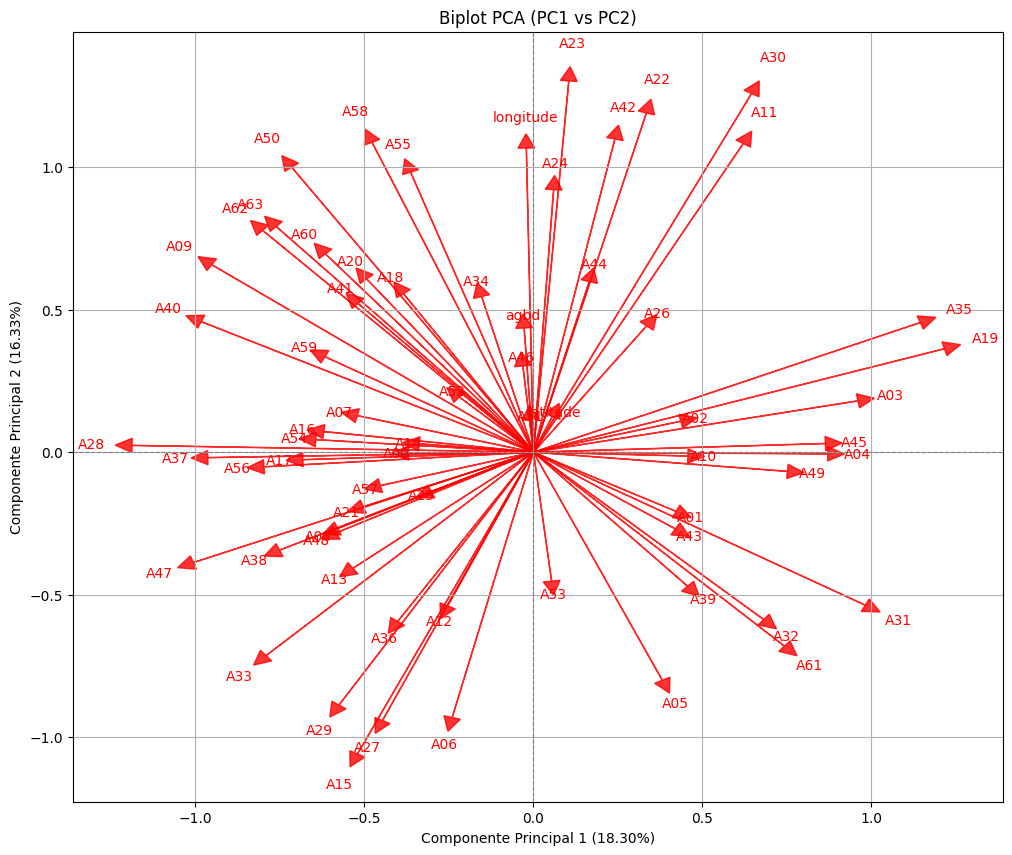

In [70]:
plt.figure(figsize=(12, 10))

# Añadir los vectores de las variables originales (embeddings)
# Obtener los loadings de los primeros 2 componentes principales
loadings = pca.components_.T[:, :2]

# Nombres de las variables originales (embeddings, coordenadas, biomasa)
# These should match the order of features passed to PCA in the previous cell.
feature_names_for_pca = [col for col in df_final.columns if col.startswith('A')] + ['longitude', 'latitude', 'agbd']

# Escalar los loadings para que sean visibles en el mismo gráfico que los puntos
# Multiplicamos por un factor para ajustar la longitud de los vectores
# Ajusta el 'scale_factor' si los vectores son muy pequeños o muy grandes
scale_factor = 5 # Puedes ajustar este valor

for i, col_name in enumerate(feature_names_for_pca):
    plt.arrow(0, 0, loadings[i, 0] * scale_factor, loadings[i, 1] * scale_factor, color='r', alpha=0.8, head_width=0.05, head_length=0.05)
    plt.text(loadings[i, 0] * scale_factor * 1.1, loadings[i, 1] * scale_factor * 1.1, col_name, color='r', ha='center', va='center')

plt.title('Biplot PCA (PC1 vs PC2)')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.show()

# 5.Export result

In [71]:
df_final.to_csv('biomass_data.csv', index=False)
print("df_final exported successfully to 'biomass_data.csv'")

df_final exported successfully to 'biomass_data.csv'
